In [69]:
#1 - importer les librairies
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [70]:
#Chargement du fichier excel
df=pd.read_excel("Base.xlsx")

In [71]:
df.head()

,Années,Périodes,volume
0,2022,1,33
1,2022,2,17
2,2022,3,11
3,2022,4,12
4,2022,5,36


In [72]:
#Constitution d'une colonne temps
df['date'] = pd.to_datetime(
    df['Années'].astype(str) + '-' + df['Périodes'].astype(str) + '-01'
)

print(df.head())


   Années  Périodes  volume       date
0    2022         1      33 2022-01-01
1    2022         2      17 2022-02-01
2    2022         3      11 2022-03-01
3    2022         4      12 2022-04-01
4    2022         5      36 2022-05-01


In [73]:
# Renommer Xt en volume pour plus de clarté dans la suite du travail
df = df.rename(columns={'Xt': 'volume'})

# Ne garder que les colonnes utiles, dans l'ordre logique
df = df[['date', 'Années', 'Périodes', 'volume']]

# Trier par date pour être certaine de l'ordre chronologique
df = df.sort_values('date').reset_index(drop=True)

print(df)

         date  Années  Périodes  volume
0  2022-01-01    2022         1      33
1  2022-02-01    2022         2      17
2  2022-03-01    2022         3      11
3  2022-04-01    2022         4      12
4  2022-05-01    2022         5      36
5  2022-06-01    2022         6      87
6  2022-07-01    2022         7     285
7  2022-08-01    2022         8     239
8  2022-09-01    2022         9     110
9  2022-10-01    2022        10      16
10 2022-11-01    2022        11      25
11 2022-12-01    2022        12      40
12 2023-01-01    2023         1      42
13 2023-02-01    2023         2      29
14 2023-03-01    2023         3       5
15 2023-04-01    2023         4       5
16 2023-05-01    2023         5      55
17 2023-06-01    2023         6     302
18 2023-07-01    2023         7     295
19 2023-08-01    2023         8     264
20 2023-09-01    2023         9      86
21 2023-10-01    2023        10      19
22 2023-11-01    2023        11      28
23 2023-12-01    2023        12      65


### NETTOYAGE DES DONNEES

In [74]:
# Vérifier qu'il n'y a pas de valeurs manquantes
df.isna().sum()

date        0
Années      0
Périodes    0
volume      0
dtype: int64

In [75]:
# Vérifier qu'il n'y a pas de doublons de dates
df['date'].duplicated().sum()

np.int64(0)

In [76]:
# Vérifier la continuité — combien de mois entre la première et la dernière date
df['date'].min(), "→", df['date'].max()
print("Nombre de lignes:", len(df))

Nombre de lignes: 48


In [138]:
# Paramètre économique
TARIF_UNITAIRE = 310000  # FCFA par dossier

# Création du chiffre d'affaires
df['ca'] = df['volume'] * TARIF_UNITAIRE

In [78]:
df.head()

,date,Années,Périodes,volume,ca
0,2022-01-01,2022,1,33,10230000
1,2022-02-01,2022,2,17,5270000
2,2022-03-01,2022,3,11,3410000
3,2022-04-01,2022,4,12,3720000
4,2022-05-01,2022,5,36,11160000


### ANALYSE EXPLORATOIRE DE LA SERIE 

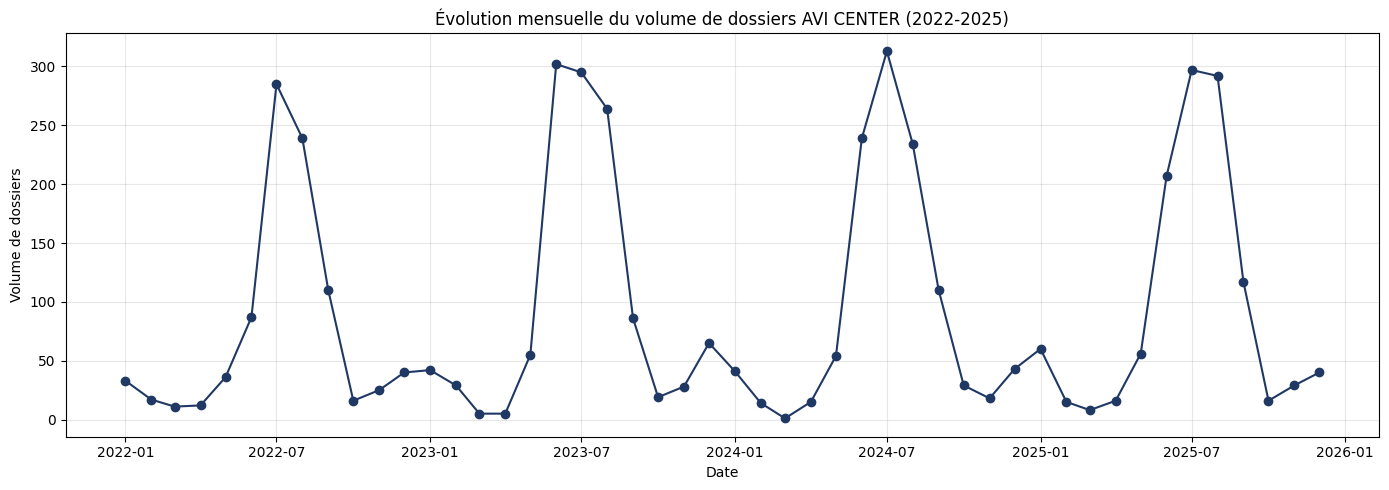

In [79]:
#Visualisation de la série 
plt.figure(figsize=(14,5))
plt.plot(df['date'], df['volume'], marker='o', linewidth=1.5, color='#1F3864')
plt.title("Évolution mensuelle du volume de dossiers AVI CENTER (2022-2025)")
plt.xlabel("Date")
plt.ylabel("Volume de dossiers")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
#Calcul des statistiques annuelles
stats_annuelles = df.groupby('Années')['volume'].agg(['sum','mean','std','min','max'])
stats_annuelles.columns = ['Total','Moyenne','Ecart-type','Min','Max']
print(stats_annuelles)

        Total    Moyenne  Ecart-type  Min  Max
Années                                        
2022      911  75.916667   92.576709   11  285
2023     1195  99.583333  115.746163    5  302
2024     1111  92.583333  107.500070    1  313
2025     1153  96.083333  108.378510    8  297


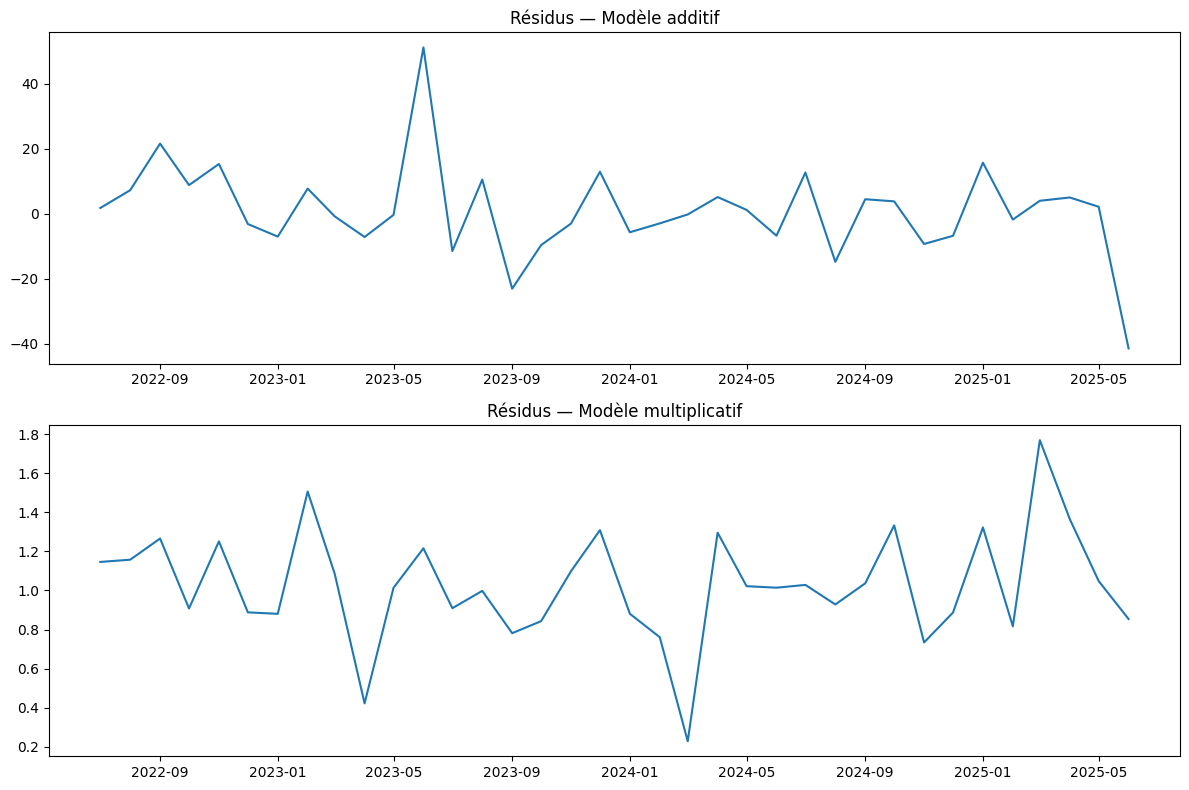

In [81]:
#Décomposition de la série temporelle
#Comparaison visuelle des models de décomposition
from statsmodels.tsa.seasonal import seasonal_decompose

df_index = df.set_index('date')['volume']

decomp_add = seasonal_decompose(df_index, model='additive', period=12)
decomp_mult = seasonal_decompose(df_index, model='multiplicative', period=12)

fig, axes = plt.subplots(2, 1, figsize=(12,8))
axes[0].plot(decomp_add.resid)
axes[0].set_title("Résidus — Modèle additif")
axes[1].plot(decomp_mult.resid)
axes[1].set_title("Résidus — Modèle multiplicatif")
plt.tight_layout()
plt.show()

In [82]:
# Modèle additif *(en haut)*
#Les résidus oscillent **autour de zéro**, avec une amplitude globalement stable dans le temps *(entre -20 et +20 la plupart du temps)*,
# à l'exception de deux pics isolés *(+50 et -40)*. Le comportement general reste régulier, sans dérive ni élargissement progressif.

# Modèle multiplicatif *(en bas)*
#Les résidus oscillent autour de **1**, mais on observe deux chutes très marquées, presque jusqu'à 0. 
# Une valeur aussi proche de 0 signifie que le modèle s'est trompé de façon **extrême** à ces moments-là *(la valeur réelle était quasiment nulle comparée à ce que le modèle attendait)* 
# — c'est un signe d'instabilité plus sévère que ce qu'on voit sur le modèle additif.

# Conclusion simple

# Le modèle additif produit des résidus **plus réguliers et plus contenus** dans le temps, sans écart extrême récurrent. 
# Le modèle multiplicatif, à l'inverse, montre des **chutes brutales et très prononcées** à certains mois, signe que ce modèle s'ajuste moins bien lorsque le volume d'activité est faible. 
# Cette meilleure stabilité des résidus confirme que le **modèle additif est le plus adapté** pour décrire l'évolution de l'activité d'AVI CENTER.
#*"L'inspection visuelle des résidus confirme la pertinence du modèle additif : ses résidus oscillent de façon stable autour de zéro sur l'ensemble de la période, 
# sans dérive marquée. À l'inverse, le modèle multiplicatif présente des chutes ponctuelles très prononcées, proches de zéro, 
# traduisant une instabilité plus importante notamment lors des mois à faible volume d'activité. Le modèle additif a donc été retenu pour la suite de l'analyse."*

In [83]:
#Test de stationnarité
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['volume'])

print("Statistique ADF :", result[0])
print("p-value :", result[1])
print("Valeurs critiques :", result[4])

if result[1] < 0.05:
    print("→ La série est stationnaire (on rejette H0)")
else:
    print("→ La série n'est PAS stationnaire (on ne rejette pas H0)")

Statistique ADF : -2.585962772104848
p-value : 0.0959333219774734
Valeurs critiques : {'1%': np.float64(-3.6209175221605827), '5%': np.float64(-2.9435394610388332), '10%': np.float64(-2.6104002410518627)}
→ La série n'est PAS stationnaire (on ne rejette pas H0)


In [84]:
#Identification des pics et creux de la série 
# Moyenne de volume par mois, toutes années confondues
moyenne_par_mois = df.groupby('Périodes')['volume'].mean().sort_values(ascending=False)
print(moyenne_par_mois)

Périodes
7     297.50
8     257.25
6     208.75
9     105.75
5      50.25
12     47.00
1      44.00
11     25.00
10     20.00
2      18.75
4      12.00
3       6.25
Name: volume, dtype: float64


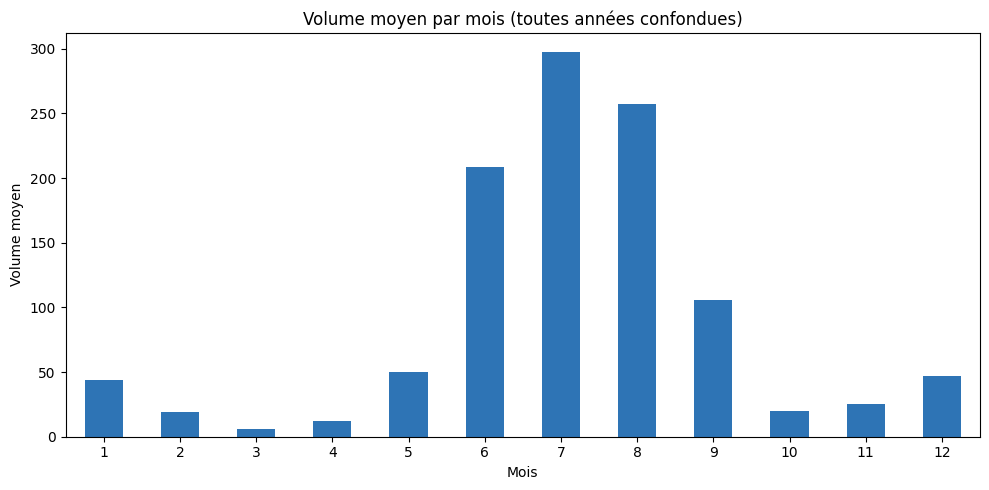

In [85]:
#Visualisation des pics et creux
plt.figure(figsize=(10,5))
moyenne_par_mois.sort_index().plot(kind='bar', color='#2E74B5')
plt.title("Volume moyen par mois (toutes années confondues)")
plt.xlabel("Mois")
plt.ylabel("Volume moyen")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### FEATURE ENGINEERING

In [86]:
#Création des variables calendaires
# Le mois et le trimestre permettent au modèle de "savoir" à quelle période
# de l'année correspond chaque observation. Sans cette variable, XGBoost
# ne peut absolument pas détecter que juillet est structurellement différent
# de mars — ce sont ces variables qui portent la saisonnalité annuelle
# dans un modèle qui, par nature, ne comprend pas le temps.

df['mois'] = df['date'].dt.month
df['trimestre'] = df['date'].dt.quarter

df[['date','mois','trimestre']].head()

,date,mois,trimestre
0,2022-01-01,1,1
1,2022-02-01,2,1
2,2022-03-01,3,1
3,2022-04-01,4,2
4,2022-05-01,5,2


In [87]:
#Variables saisonnières
df['saison'] = df['mois'].apply(lambda m: 1 if m in [6,7,8] else 0)

df[['date','mois','saison']].head(15)
# Cette variable binaire renforce explicitement le signal saisonnier déjà
# présent dans "mois". Les modèles à base d'arbres apprennent parfois
# plus facilement une règle simple (haute/basse saison) qu'une variable
# à 12 modalités — cela réduit la complexité de la décision à apprendre.

,date,mois,saison
0,2022-01-01,1,0
1,2022-02-01,2,0
2,2022-03-01,3,0
3,2022-04-01,4,0
4,2022-05-01,5,0
5,2022-06-01,6,1
6,2022-07-01,7,1
7,2022-08-01,8,1
8,2022-09-01,9,0
9,2022-10-01,10,0


In [88]:
# lag_1 et lag_2 donnent au modèle une mémoire du passé immédiat :
# le volume du mois précédent, et celui d'il y a 2 mois. L'objectif est
# de capter une éventuelle dynamique de court terme (momentum) —
# si l'activité était forte le mois dernier, l'est-elle encore ce mois-ci ?
#
# ATTENTION : leur pertinence n'est pas garantie a priori dans un contexte
# de forte saisonnalité comme le nôtre, où les sauts d'un mois à l'autre
# sont dictés par le cycle saisonnier plutôt que par une vraie inertie.
# Leur utilité doit donc être vérifiée empiriquement avant d'être admise
# (voir étape 3.4 ci-dessous).

df['lag_1'] = df['volume'].shift(1)
df['lag_2'] = df['volume'].shift(2)

df[['date','volume','lag_1','lag_2']].head(10)

,date,volume,lag_1,lag_2
0,2022-01-01,33,NaN,NaN
1,2022-02-01,17,33.0,NaN
2,2022-03-01,11,17.0,33.0
3,2022-04-01,12,11.0,17.0
4,2022-05-01,36,12.0,11.0
5,2022-06-01,87,36.0,12.0
6,2022-07-01,285,87.0,36.0
7,2022-08-01,239,285.0,87.0
8,2022-09-01,110,239.0,285.0
9,2022-10-01,16,110.0,239.0


### 3.4 — Vérification de la pertinence des lags courts
#### 3.4.1 — Autocorrélation (ACF/PACF)

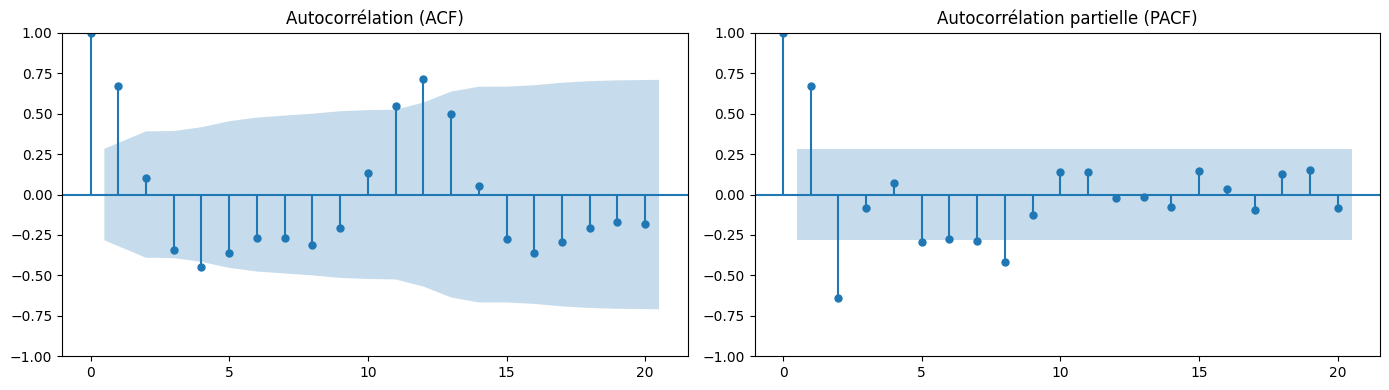

In [89]:
# L'ACF et la PACF permettent de mesurer objectivement la force du lien
# entre le volume actuel et ses valeurs passées, à différents décalages.
# On vérifie ici si le lag 1 et le lag 2 sortent significatifs
# (en dehors de la zone bleue = intervalle de confiance),
# ou si c'est un lag plus lointain (ex: lag 12) qui domine le signal.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(df['volume'], lags=20, ax=axes[0])
axes[0].set_title("Autocorrélation (ACF)")
plot_pacf(df['volume'], lags=20, ax=axes[1])
axes[1].set_title("Autocorrélation partielle (PACF)")
plt.tight_layout()
plt.show()



#### 3.4.3 — Conclusion sur la pertinence de lag_1 et lag_2

#Lecture des résultats :**
#- Lag_1 : significatif en ACF (0,67) ET en PACF (0,67) → lien direct fort
#- Lag_2 : non significatif en ACF (0,10) mais fortement significatif en 
  PACF (-0,65) → effet propre distinct, une fois lag_1 retiré (typique 
  d'une structure AR(2))
- Constat complémentaire : les lags 11 à 13 (notamment lag_12 = 0,72) sont 
  les plus significatifs du graphique, confirmant statistiquement la 
  dominance de la saisonnalité annuelle déjà identifiée en Phase 2.

#Conclusion retenue :** Lag_1 et lag_2 sont tous deux conservés dans le 
modèle — Cas 1. Leur pertinence est confirmée empiriquement, notamment 
via la PACF qui révèle un effet propre significatif de lag_2 masqué dans 
l'ACF brute.
#Décision pour la suite de l'analyse :** Utilisation de l'Option A 
(dataset avec lag_1 et lag_2). La non-inclusion de lag_12 — pourtant 
identifié comme fortement significatif — est assumée comme une limite 
méthodologique liée à la contrainte de taille d'échantillon (48 

In [90]:
# La moyenne mobile sur 3 mois lisse les fluctuations ponctuelles et
# donne au modèle une indication de la dynamique récente de l'activité,
# indépendamment de l'effet saisonnier pur capté par "mois" et "saison".
# Elle permet de distinguer un pic isolé d'une vraie accélération
# de tendance sur plusieurs mois consécutifs.

df['moyenne_mobile_3'] = df['volume'].rolling(window=3).mean()

df[['date','volume','moyenne_mobile_3']].head(10)

,date,volume,moyenne_mobile_3
0,2022-01-01,33,NaN
1,2022-02-01,17,NaN
2,2022-03-01,11,20.333333
3,2022-04-01,12,13.333333
4,2022-05-01,36,19.666667
5,2022-06-01,87,45.000000
6,2022-07-01,285,136.000000
7,2022-08-01,239,203.666667
8,2022-09-01,110,211.333333
9,2022-10-01,16,121.666667


In [91]:
# Ne garder que les colonnes utiles selon la conclusion de l'étape 3.4.

df_ml = df[['date','volume','mois','trimestre','saison',
            'lag_1','lag_2','moyenne_mobile_3']].copy()


df_ml = df_ml.dropna().reset_index(drop=True)

print("Nombre de lignes dans le dataset final :", len(df_ml))
df_ml.head()

Nombre de lignes dans le dataset final : 46


,date,volume,mois,trimestre,saison,lag_1,lag_2,moyenne_mobile_3
0,2022-03-01,11,3,1,0,17.0,33.0,20.333333
1,2022-04-01,12,4,2,0,11.0,17.0,13.333333
2,2022-05-01,36,5,2,0,12.0,11.0,19.666667
3,2022-06-01,87,6,2,1,36.0,12.0,45.000000
4,2022-07-01,285,7,3,1,87.0,36.0,136.000000


In [92]:
print("Colonnes retenues :", list(df_ml.columns))
print("Valeurs manquantes restantes :\n", df_ml.isnull().sum())
print("Période couverte :", df_ml['date'].min(), "→", df_ml['date'].max())

Colonnes retenues : ['date', 'volume', 'mois', 'trimestre', 'saison', 'lag_1', 'lag_2', 'moyenne_mobile_3']
Valeurs manquantes restantes :
 date                0
volume              0
mois                0
trimestre           0
saison              0
lag_1               0
lag_2               0
moyenne_mobile_3    0
dtype: int64
Période couverte : 2022-03-01 00:00:00 → 2025-12-01 00:00:00


In [93]:
#Vérification du trie chronologique 
df_ml = df_ml.sort_values('date').reset_index(drop=True)
print(df_ml['date'].is_monotonic_increasing)  # doit afficher True

True


### SPLIT TRAIN\TEST CHRONOLOGIQUE

In [94]:
#Réalisation du split
# Vérification préalable : le dataset doit être trié chronologiquement
df_ml = df_ml.sort_values('date').reset_index(drop=True)
assert df_ml['date'].is_monotonic_increasing, "Le dataset n'est pas trié !"

# Définition de la date de coupure
split_date = '2025-01-01'

# Split chronologique strict — jamais de mélange aléatoire ici
train = df_ml[df_ml['date'] < split_date].reset_index(drop=True)
test = df_ml[df_ml['date'] >= split_date].reset_index(drop=True)

print("Train :", train['date'].min(), "→", train['date'].max(), "|", len(train), "observations")
print("Test  :", test['date'].min(), "→", test['date'].max(), "|", len(test), "observations")

Train : 2022-03-01 00:00:00 → 2024-12-01 00:00:00 | 34 observations
Test  : 2025-01-01 00:00:00 → 2025-12-01 00:00:00 | 12 observations


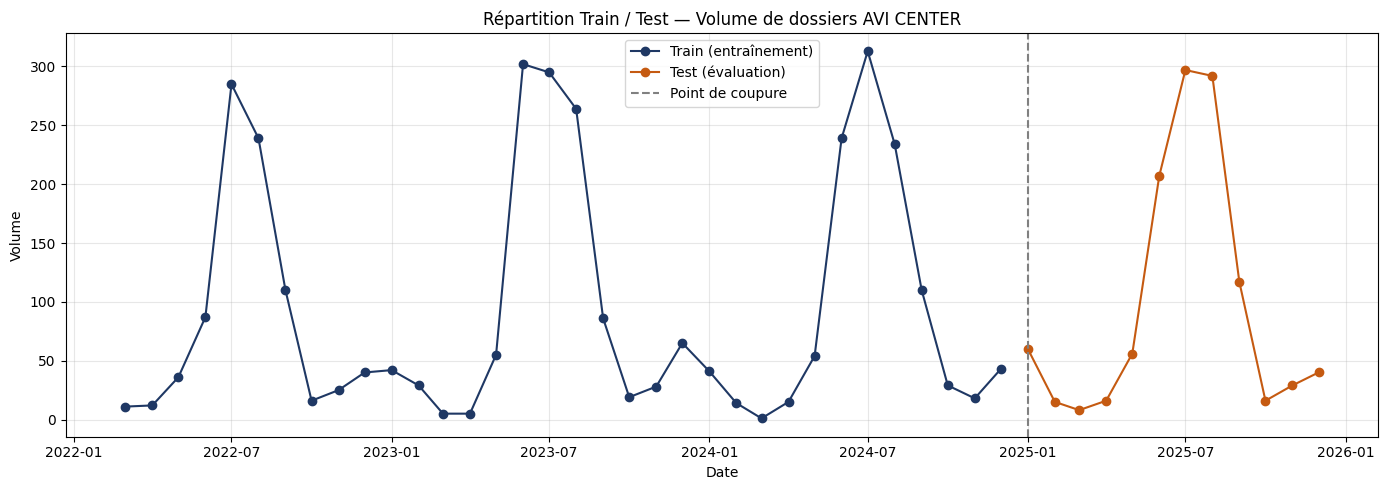

In [95]:
#Visualisation du split

plt.figure(figsize=(14,5))
plt.plot(train['date'], train['volume'], label='Train (entraînement)', color='#1F3864', marker='o')
plt.plot(test['date'], test['volume'], label='Test (évaluation)', color='#C55A11', marker='o')
plt.axvline(x=pd.to_datetime(split_date), color='gray', linestyle='--', label='Point de coupure')
plt.title("Répartition Train / Test — Volume de dossiers AVI CENTER")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [96]:
# On sépare les variables explicatives (features) de la variable cible
# (volume). C'est cette structure X / y qu'attendent tous les modèles
# scikit-learn / XGBoost pour l'entraînement.

features = ['mois', 'trimestre', 'saison', 'lag_1', 'lag_2', 'moyenne_mobile_3']

X_train = train[features]
y_train = train['volume']

X_test = test[features]
y_test = test['volume']

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

X_train : (34, 6)
X_test  : (12, 6)


In [97]:
# Contrôle qu'il n'y a aucune valeur manquante dans les jeux finaux
print("NaN dans X_train :", X_train.isnull().sum().sum())
print("NaN dans X_test  :", X_test.isnull().sum().sum())

# Aperçu final
X_train.head()

NaN dans X_train : 0
NaN dans X_test  : 0


,mois,trimestre,saison,lag_1,lag_2,moyenne_mobile_3
0,3,1,0,17.0,33.0,20.333333
1,4,2,0,11.0,17.0,13.333333
2,5,2,0,12.0,11.0,19.666667
3,6,2,1,36.0,12.0,45.000000
4,7,3,1,87.0,36.0,136.000000


### ENTRAINEMENT DES MODELS DE MACHINE LEARNING

In [98]:
### 5.1 — Prophet

#Prophet est un modèle développé par Meta, spécialement conçu pour les
# séries temporelles avec forte saisonnalité et peu d'observations —
# exactement notre cas. Il détecte automatiquement la tendance et la
# saisonnalité annuelle sans nécessiter de feature engineering manuel.
# Il utilise ici la série brute complète (df), pas df_ml, car il n'a pas
# besoin des variables lag_1/lag_2/moyenne_mobile_3.

In [99]:
from prophet import Prophet

# Prophet exige un format précis : colonnes nommées 'ds' (date) et 'y' (valeur)
df_prophet = df[['date','volume']].rename(columns={'date':'ds','volume':'y'})

# Split cohérent avec la même date de coupure que les autres modèles
train_prophet = df_prophet[df_prophet['ds'] < split_date]
test_prophet = df_prophet[df_prophet['ds'] >= split_date]

# Entraînement — yearly_seasonality=True force la détection du cycle annuel
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_prophet.fit(train_prophet)

# Prévision sur la période de test (12 mois)
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq='MS')
forecast_prophet = model_prophet.predict(future)

# Extraction des prédictions correspondant uniquement à la période de test
pred_prophet = forecast_prophet[forecast_prophet['ds'] >= split_date]['yhat'].values

print("Prédictions Prophet (2025) :")
print(pred_prophet)

12:16:46 - cmdstanpy - INFO - Chain [1] start processing
12:16:47 - cmdstanpy - INFO - Chain [1] done processing


Prédictions Prophet (2025) :
[ 70.82208699  63.0227378   23.40982699  33.14229755  70.78816157
 227.28559477 325.39401727 262.62953801 129.13862024  45.2369622
  41.59114195  64.60957975]


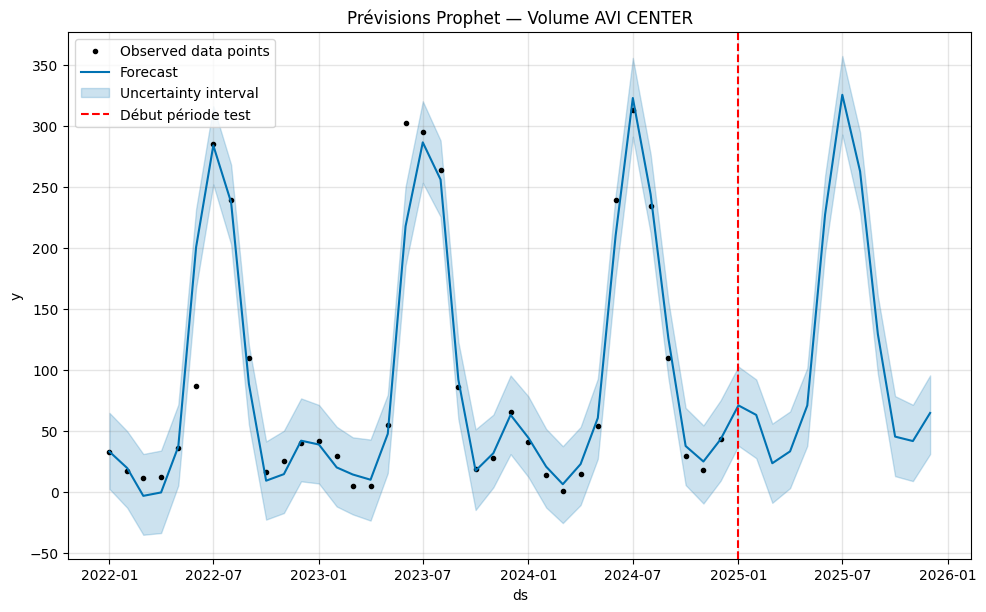

In [100]:
#Visualisation 
fig = model_prophet.plot(forecast_prophet)
plt.axvline(x=pd.to_datetime(split_date), color='red', linestyle='--', label='Début période test')
plt.title("Prévisions Prophet — Volume AVI CENTER")
plt.legend()
plt.show()

In [101]:
# 5.2 — XGBoost

#XGBoost utilise les variables construites en Phase 3 (mois, trimestre,
# saison, lag_1, lag_2, moyenne_mobile_3). Contrairement à Prophet, il ne
# "comprend" pas le temps nativement — c'est tout le travail de feature
# engineering réalisé précédemment qui lui permet de capter la saisonnalité
# et la dynamique de la série.

In [102]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=3,        # profondeur limitée : dataset petit, éviter le surapprentissage
    learning_rate=0.1,
    random_state=42
)

model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

print("Prédictions XGBoost (2025) :")
print(pred_xgb)

Prédictions XGBoost (2025) :
[ 44.36353   20.520624   9.58201   13.108365  54.5458   291.95477
 289.23038  250.37013   86.69822   24.629187  24.026678  42.39286 ]


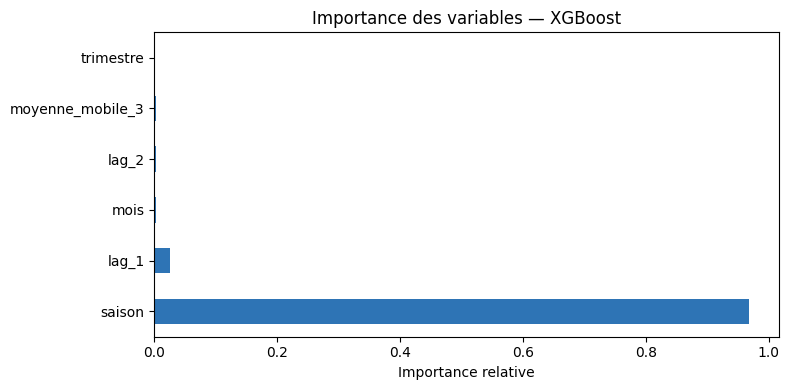

In [103]:
# Vérification directe de la pertinence des variables (confirmation Phase 3)
importances = pd.Series(model_xgb.feature_importances_, index=features)
importances.sort_values(ascending=False).plot(kind='barh', figsize=(8,4), color='#2E74B5')
plt.title("Importance des variables — XGBoost")
plt.xlabel("Importance relative")
plt.tight_layout()
plt.show()

In [104]:
### 5.3 — Random Forest

#Modèle de comparaison au sein même de la famille Machine Learning. Il
# utilise les mêmes variables que XGBoost mais repose sur un principe
# d'agrégation différent (moyenne de nombreux arbres indépendants plutôt
# que correction successive des erreurs). Sa comparaison avec XGBoost
# permet de vérifier la robustesse du choix de modèle ML final.

In [105]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    random_state=42
)

model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

print("Prédictions Random Forest (2025) :")
print(pred_rf)

Prédictions Random Forest (2025) :
[ 39.4257314   21.87291573  12.85918203  19.25027585  45.60175656
 251.298      290.30910317 247.52105556  98.66008333  54.84507099
  22.37576307  44.37842156]


In [106]:
## 5.4 — SARIMA (modèle de référence économétrique)

#SARIMA sert de baseline économétrique classique, pour objectiver
# l'apport réel du Machine Learning par rapport à une approche
# statistique traditionnelle. Il utilise la série brute (comme Prophet),
# et intègre automatiquement la différenciation nécessaire pour gérer
# la non-stationnarité identifiée en Phase 2 (test ADF).Les ordres (p,d,q)(P,D,Q,12) sont ici fixés à des valeurs de départ
# raisonnables ; une recherche par grille (auto_arima) peut affiner
# ce choix si le temps le permet.

In [107]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_sarima = df[df['date'] < split_date].set_index('date')['volume']
test_sarima = df[df['date'] >= split_date].set_index('date')['volume']

model_sarima = SARIMAX(
    train_sarima,
    order=(1,1,1),            # d=1 : différenciation simple (série non stationnaire)
    seasonal_order=(1,1,1,12) # composante saisonnière sur cycle de 12 mois
)
result_sarima = model_sarima.fit(disp=False)

pred_sarima = result_sarima.forecast(steps=len(test_sarima))

print("Prédictions SARIMA (2025) :")
print(pred_sarima)

c:\Users\TYFFANI\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\TYFFANI\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\TYFFANI\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Prédictions SARIMA (2025) :
2025-01-01     50.813540
2025-02-01     32.085919
2025-03-01      8.691767
2025-04-01     17.089080
2025-05-01     69.629714
2025-06-01    348.600441
2025-07-01    318.134750
2025-08-01    262.653502
2025-09-01    100.691736
2025-10-01     34.713999
2025-11-01     31.244411
2025-12-01     68.762339
Freq: MS, Name: predicted_mean, dtype: float64


c:\Users\TYFFANI\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [108]:
#Visualisation des résultats obtenus à partir des models utilisés
resultats = pd.DataFrame({
    'date': test['date'].values,
    'reel': y_test.values,
    'prophet': pred_prophet,
    'xgboost': pred_xgb,
    'random_forest': pred_rf,
    'sarima': pred_sarima.values
})

resultats

,date,reel,prophet,xgboost,random_forest,sarima
0,2025-01-01,60,70.822087,44.363529,39.425731,50.813540
1,2025-02-01,15,63.022738,20.520624,21.872916,32.085919
2,2025-03-01,8,23.409827,9.582010,12.859182,8.691767
3,2025-04-01,16,33.142298,13.108365,19.250276,17.089080
4,2025-05-01,56,70.788162,54.545799,45.601757,69.629714
5,2025-06-01,207,227.285595,291.954773,251.298000,348.600441
6,2025-07-01,297,325.394017,289.230377,290.309103,318.134750
7,2025-08-01,292,262.629538,250.370132,247.521056,262.653502
8,2025-09-01,117,129.138620,86.698219,98.660083,100.691736
9,2025-10-01,16,45.236962,24.629187,54.845071,34.713999


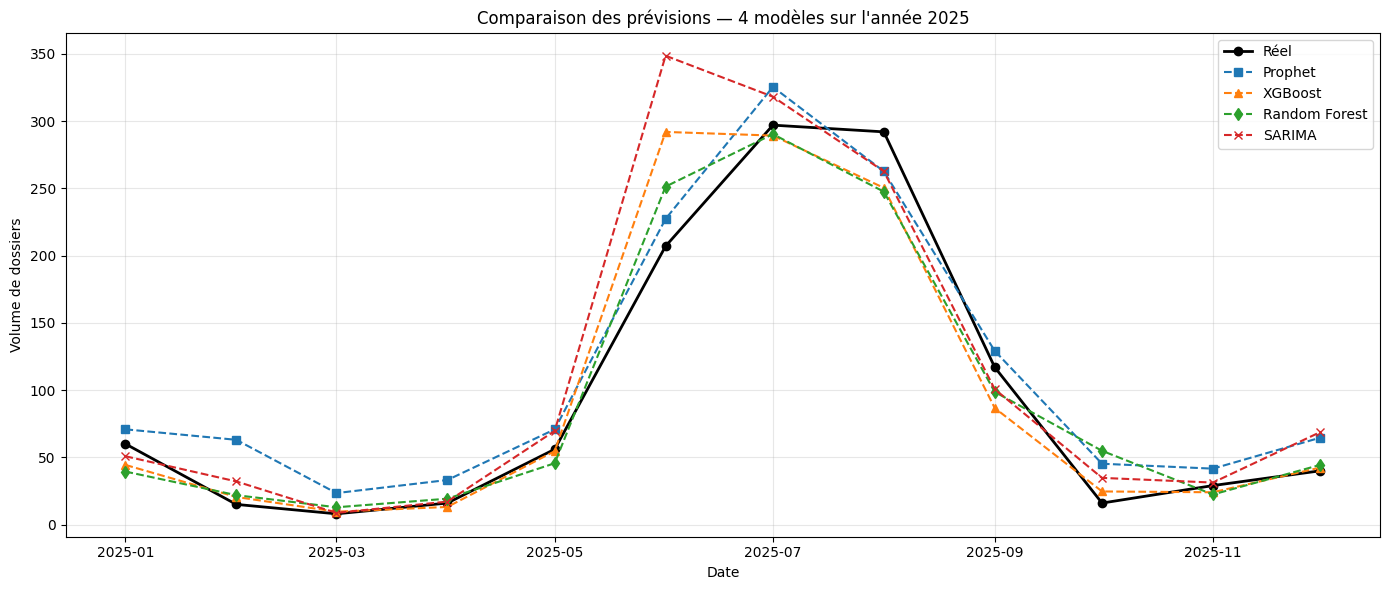

In [109]:
#Visualisation des 4 models
plt.figure(figsize=(14,6))
plt.plot(resultats['date'], resultats['reel'], label='Réel', color='black', marker='o', linewidth=2)
plt.plot(resultats['date'], resultats['prophet'], label='Prophet', linestyle='--', marker='s')
plt.plot(resultats['date'], resultats['xgboost'], label='XGBoost', linestyle='--', marker='^')
plt.plot(resultats['date'], resultats['random_forest'], label='Random Forest', linestyle='--', marker='d')
plt.plot(resultats['date'], resultats['sarima'], label='SARIMA', linestyle='--', marker='x')
plt.title("Comparaison des prévisions — 4 modèles sur l'année 2025")
plt.xlabel("Date")
plt.ylabel("Volume de dossiers")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [110]:
#COMMENTAIRES
#"L'analyse visuelle des prévisions sur l'année 2025 révèle que la période de transition saisonnière (juin) constitue le principal point de divergence entre modèles, 
# avec une surestimation particulièrement marquée du modèle SARIMA (+142 dossiers par rapport au réel), tandis que Prophet présente à l'inverse un biais haussier systématique 
# et modéré durant les mois de basse saison. Les quatre modèles convergent en revanche sur la période de pic (juillet-août), 
# suggérant une meilleure capacité collective à modéliser le cœur de la saison haute que sa phase de transition."

### 5.7 — Validation par fenêtre glissante (walk-forward validation)

Le split unique (5.1 à 5.6) permet de comparer les modèles entre eux,
mais ne mesure pas comment l'erreur évolue selon l'horizon de prévision
en mode récursif — pertinent uniquement pour XGBoost, seul modèle
utilisant une logique de lags dans ce mémoire (Prophet et SARIMA
gèrent l'horizon nativement, sans dépendance à leurs propres
prédictions passées de la même manière).

Cette étape prépare la fonction et les simulations nécessaires à
l'analyse d'horizon qui sera exploitée en Phase 6.7.

In [111]:
#Définition de la fonction de prévision récurcive
def prevision_recursive(model, historique_connu, dates_a_predire, features_list):
    historique = historique_connu[['date','volume']].copy()
    predictions = []
    for date_cible in dates_a_predire:
        mois = date_cible.month
        trimestre = (mois - 1) // 3 + 1
        saison = 1 if mois in [6,7,8] else 0
        lag_1 = historique['volume'].iloc[-1]
        lag_2 = historique['volume'].iloc[-2]
        moyenne_mobile_3 = historique['volume'].iloc[-3:].mean()
        X_pred = pd.DataFrame([{
            'mois': mois, 'trimestre': trimestre, 'saison': saison,
            'lag_1': lag_1, 'lag_2': lag_2, 'moyenne_mobile_3': moyenne_mobile_3
        }])[features_list]
        volume_pred = model.predict(X_pred)[0]
        predictions.append({'date': date_cible, 'volume_pred': volume_pred})
        historique = pd.concat([historique,
            pd.DataFrame([{'date': date_cible, 'volume': volume_pred}])], ignore_index=True)
    return pd.DataFrame(predictions)

In [112]:
#Exécution des simulations
points_coupure = ['2023-12-01', '2024-12-01']
resultats_walkforward = []

for pc in points_coupure:
    train_wf = df_ml[df_ml['date'] <= pc]
    X_train_wf, y_train_wf = train_wf[features], train_wf['volume']

    model_wf = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    model_wf.fit(X_train_wf, y_train_wf)

    dates_test = df_ml[df_ml['date'] > pc]['date'].reset_index(drop=True)[:12]
    historique_pour_pred = df[df['date'] <= pc]
    pred_wf = prevision_recursive(model_wf, historique_pour_pred, dates_test, features)

    reel_wf = df[df['date'].isin(dates_test)][['date','volume']].reset_index(drop=True)
    comparaison = pred_wf.merge(reel_wf, on='date')
    comparaison['horizon'] = range(1, len(comparaison) + 1)
    comparaison['erreur_absolue'] = abs(comparaison['volume'] - comparaison['volume_pred'])
    comparaison['simulation'] = pc
    resultats_walkforward.append(comparaison)

df_walkforward = pd.concat(resultats_walkforward, ignore_index=True)
df_walkforward

,date,volume_pred,volume,horizon,erreur_absolue,simulation
0,2024-01-01,42.316677,41,1,1.316677,2023-12-01
1,2024-02-01,25.135088,14,2,11.135088,2023-12-01
2,2024-03-01,25.747936,1,3,24.747936,2023-12-01
3,2024-04-01,18.036983,15,4,3.036983,2023-12-01
4,2024-05-01,21.809494,54,5,32.190506,2023-12-01
5,2024-06-01,82.440224,239,6,156.559776,2023-12-01
6,2024-07-01,285.224243,313,7,27.775757,2023-12-01
7,2024-08-01,244.634476,234,8,10.634476,2023-12-01
8,2024-09-01,100.894653,110,9,9.105347,2023-12-01
9,2024-10-01,18.950274,29,10,10.049726,2023-12-01


##### Phase 6 — Évaluation et sélection du meilleur modèle

Trois métriques sont utilisées, chacune capturant un aspect différent
de la qualité prédictive :
- MAE  : erreur moyenne en nombre de dossiers (facile à interpréter)
- RMSE : pénalise davantage les grosses erreurs isolées (ex: SARIMA en juin)
- MAPE : erreur en pourcentage, facilite la comparaison entre modèles
         et la communication à la direction d'AVI CENTER

In [113]:
#Définition de la fonction de calcul des métriques
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluer(y_true, y_pred, nom_modele):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Modèle': nom_modele, 'MAE': round(mae,1), 'RMSE': round(rmse,1), 'MAPE (%)': round(mape,1)}

In [114]:
y_true = resultats['reel'].values

scores = []
scores.append(evaluer(y_true, resultats['prophet'].values, "Prophet"))
scores.append(evaluer(y_true, resultats['xgboost'].values, "XGBoost"))
scores.append(evaluer(y_true, resultats['random_forest'].values, "Random Forest"))
scores.append(evaluer(y_true, resultats['sarima'].values, "SARIMA"))

df_scores = pd.DataFrame(scores).sort_values('RMSE').reset_index(drop=True)
df_scores

,Modèle,MAE,RMSE,MAPE (%)
0,Random Forest,17.5,23.3,42.6
1,Prophet,21.9,24.2,82.7
2,XGBoost,17.3,29.3,22.0
3,SARIMA,25.0,44.1,38.8


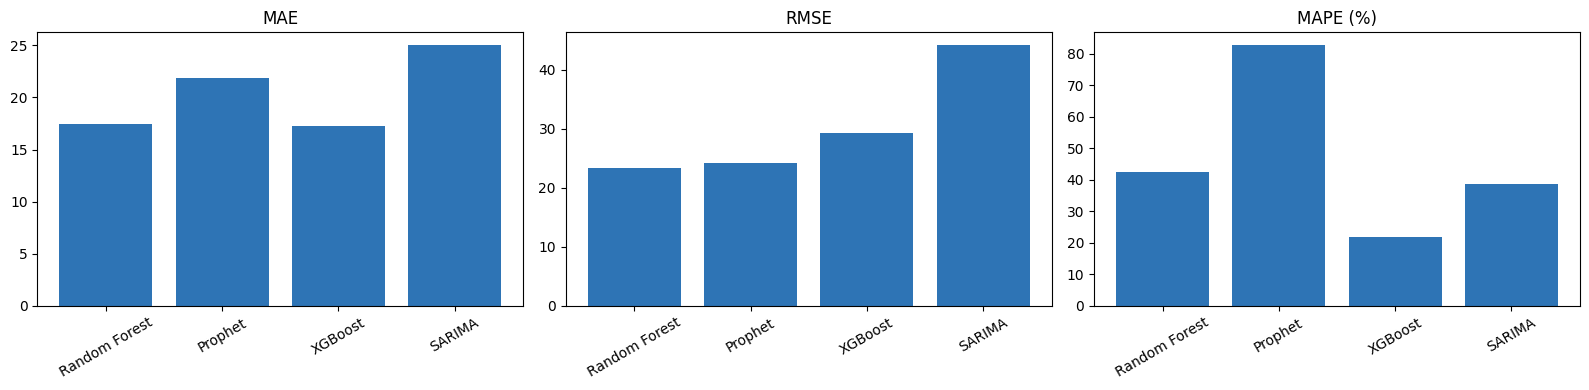

In [115]:
#Visualisation comparative des métriques
fig, axes = plt.subplots(1, 3, figsize=(16,4))

for ax, metric in zip(axes, ['MAE','RMSE','MAPE (%)']):
    ax.bar(df_scores['Modèle'], df_scores[metric], color='#2E74B5')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [116]:
#Sélection du meilleur model par métrique
print("Meilleur modèle selon MAE  :", df_scores.loc[df_scores['MAE'].idxmin(), 'Modèle'])
print("Meilleur modèle selon RMSE :", df_scores.loc[df_scores['RMSE'].idxmin(), 'Modèle'])
print("Meilleur modèle selon MAPE :", df_scores.loc[df_scores['MAPE (%)'].idxmin(), 'Modèle'])

Meilleur modèle selon MAE  : XGBoost
Meilleur modèle selon RMSE : Random Forest
Meilleur modèle selon MAPE : XGBoost


In [117]:
#Analyse des erreurs par mois
for modele in ['prophet','xgboost','random_forest','sarima']:
    resultats[f'erreur_{modele}'] = resultats['reel'] - resultats[modele]

erreurs_mensuelles = resultats[['date','erreur_prophet','erreur_xgboost',
                                  'erreur_random_forest','erreur_sarima']]
erreurs_mensuelles

,date,erreur_prophet,erreur_xgboost,erreur_random_forest,erreur_sarima
0,2025-01-01,-10.822087,15.636471,20.574269,9.186460
1,2025-02-01,-48.022738,-5.520624,-6.872916,-17.085919
2,2025-03-01,-15.409827,-1.582010,-4.859182,-0.691767
3,2025-04-01,-17.142298,2.891635,-3.250276,-1.089080
4,2025-05-01,-14.788162,1.454201,10.398243,-13.629714
5,2025-06-01,-20.285595,-84.954773,-44.298000,-141.600441
6,2025-07-01,-28.394017,7.769623,6.690897,-21.134750
7,2025-08-01,29.370462,41.629868,44.478944,29.346498
8,2025-09-01,-12.138620,30.301781,18.339917,16.308264
9,2025-10-01,-29.236962,-8.629187,-38.845071,-18.713999


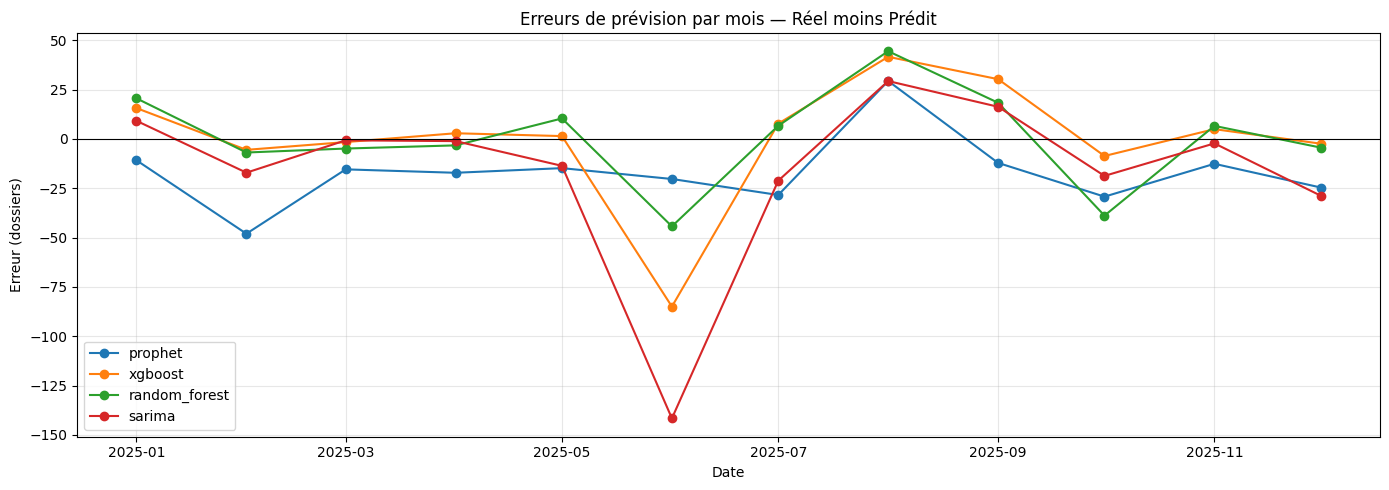

In [118]:
#Visualisation
plt.figure(figsize=(14,5))
for modele, couleur in zip(['prophet','xgboost','random_forest','sarima'],
                             ['#2E74B5','#C55A11','#1E6B3C','#C00000']):
    plt.plot(resultats['date'], resultats[f'erreur_{modele}'], label=modele, marker='o')

plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.title("Erreurs de prévision par mois — Réel moins Prédit")
plt.xlabel("Date")
plt.ylabel("Erreur (dossiers)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.6 — Sélection du modèle final


Modèle retenu : XGBoost

Justification : XGBoost présente les meilleures performances sur 2 des
3 métriques (MAE et MAPE), avec un MAPE nettement inférieur aux autres
modèles (22,0% contre 38,8% à 82,7%). Son RMSE légèrement supérieur à
celui de Random Forest s'explique par une surestimation ponctuelle lors
de la phase de transition saisonnière (juin), zone de difficulté commune
à l'ensemble des modèles testés, et non par une instabilité généralisée.
Le MAPE élevé de Prophet (82,7%) est écarté comme critère discriminant
en raison de l'instabilité mathématique connue de cette métrique sur
des valeurs réelles proches de zéro, fréquentes en basse saison.

SARIMA, dominé sur les trois métriques, confirme empiriquement l'apport
du Machine Learning par rapport à l'économétrie classique dans ce
contexte de série courte et fortement saisonnière — validant l'hypothèse
H3 du mémoire.

### 6.7 — Analyse de la fiabilité selon l'horizon (walk-forward)

Cette étape exploite les résultats de la validation par fenêtre
glissante (Phase 5.7) pour déterminer jusqu'à quel horizon les
prévisions récursives d'XGBoost restent suffisamment fiables. Ce
résultat conditionnera directement la limite des recommandations
fermes formulées en Phase 7.

In [119]:
# Vérification : l'erreur est-elle liée à l'horizon ou au mois calendaire visé ?
df_walkforward['mois_calendaire'] = df_walkforward['date'].dt.month
erreur_par_mois_calendaire = df_walkforward.groupby('mois_calendaire')['erreur_absolue'].mean().round(1)

print("Erreur moyenne par mois calendaire (toutes simulations confondues) :")
print(erreur_par_mois_calendaire)

Erreur moyenne par mois calendaire (toutes simulations confondues) :
mois_calendaire
1       9.5
2       6.1
3      16.4
4       4.4
5      30.6
6     139.7
7      16.3
8      29.2
9      11.1
10      9.3
11      5.5
12     18.1
Name: erreur_absolue, dtype: float64


In [120]:
#Calcul de l'erreur par horizon 
erreur_par_horizon = df_walkforward.groupby('horizon')['erreur_absolue'].mean().round(1)
print("Erreur moyenne absolue selon l'horizon de prévision :")
print(erreur_par_horizon)

Erreur moyenne absolue selon l'horizon de prévision :
horizon
1       9.5
2       6.1
3      16.4
4       4.4
5      30.6
6     139.7
7      16.3
8      29.2
9      11.1
10      9.3
11      5.5
12     18.1
Name: erreur_absolue, dtype: float64


In [121]:
#Analyse par mois calendaire
df_walkforward['mois_calendaire'] = df_walkforward['date'].dt.month
erreur_par_mois_calendaire = df_walkforward.groupby('mois_calendaire')['erreur_absolue'].mean().round(1)
print(erreur_par_mois_calendaire)

mois_calendaire
1       9.5
2       6.1
3      16.4
4       4.4
5      30.6
6     139.7
7      16.3
8      29.2
9      11.1
10      9.3
11      5.5
12     18.1
Name: erreur_absolue, dtype: float64


In [122]:
mae_modele = 17.3  # MAE d'XGBoost obtenu en 6.2
seuil_acceptable = mae_modele * 1.5

# CORRECTION : on cherche le premier horizon en échec, pas le max des horizons valides
horizons_en_echec = erreur_par_horizon[erreur_par_horizon > seuil_acceptable].index

if len(horizons_en_echec) > 0:
    horizon_fiable = horizons_en_echec.min() - 1
else:
    horizon_fiable = 12

# Sécurité : éviter un horizon négatif ou nul si même le mois 1 échoue
horizon_fiable = max(horizon_fiable, 1)

print("Horizons en échec (erreur > seuil) :", list(horizons_en_echec))
print("Horizon fiable retenu (règle corrigée — premier point de rupture) :", horizon_fiable)

Horizons en échec (erreur > seuil) : [5, 6, 8]
Horizon fiable retenu (règle corrigée — premier point de rupture) : 4


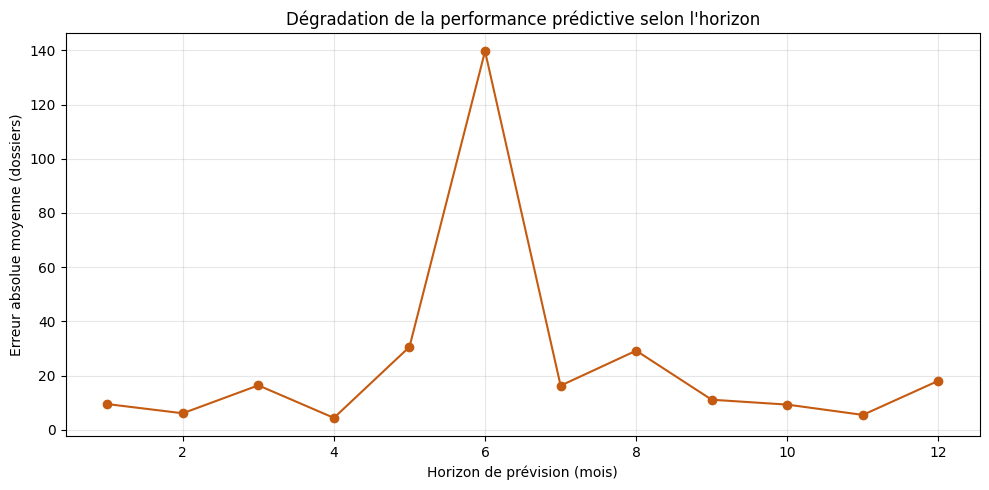

In [123]:
#Visualisation
plt.figure(figsize=(10,5))
plt.plot(erreur_par_horizon.index, erreur_par_horizon.values, marker='o', color='#C55A11')
plt.title("Dégradation de la performance prédictive selon l'horizon")
plt.xlabel("Horizon de prévision (mois)")
plt.ylabel("Erreur absolue moyenne (dossiers)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [124]:
# Détermination de l'horizon fiable
mae_modele = 17.3
seuil_acceptable = mae_modele * 1.5

horizons_en_echec = erreur_par_horizon[
    erreur_par_horizon > seuil_acceptable
].index

if len(horizons_en_echec) > 0:
    horizon_fiable = int(horizons_en_echec.min() - 1)
else:
    horizon_fiable = 12

horizon_fiable = max(horizon_fiable, 1)

print("MAE de référence :", mae_modele)
print("Seuil acceptable :", round(seuil_acceptable, 2))
print("Horizons en échec :", list(horizons_en_echec))
print("Horizon fiable retenu :", horizon_fiable)

MAE de référence : 17.3
Seuil acceptable : 25.95
Horizons en échec : [5, 6, 8]
Horizon fiable retenu : 4


## PHASE7- REENTRAINEMENT ET PREVISIONS

### 7.1 — Réentraînement du modèle final

Le modèle retenu (XGBoost) est réentraîné sur l'ensemble des données
disponibles (2022-2025), et non plus seulement sur la période
d'entraînement de la Phase 4. L'objectif n'est plus d'évaluer le modèle
(déjà fait en Phase 6) mais de maximiser l'information disponible avant
de produire de véritables prévisions sur du futur inconnu (2026+).

In [125]:
# On regroupe train + test pour ré-entraîner sur l'intégralité de l'historique
X_full = df_ml[features]
y_full = df_ml['volume']

model_final = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
model_final.fit(X_full, y_full)

print("Modèle final entraîné sur", len(X_full), "observations (mars 2022 - décembre 2025)")

Modèle final entraîné sur 46 observations (mars 2022 - décembre 2025)


### 7.2 — Construction des variables futures pour 2026

MODIFICATION liée au Levier 3 : la prévision récursive n'est désormais
générée que sur l'horizon jugé fiable (horizon_fiable, déterminé en
Phase 6.7), et non plus systématiquement sur 12 mois. Les mois
au-delà de cet horizon seront traités séparément en 7.2bis, avec un
statut explicitement indicatif.

In [126]:
dates_futures = pd.date_range('2026-01-01', periods=horizon_fiable, freq='MS')

print(f"Prévisions fermes générées sur {horizon_fiable} mois : "
      f"{dates_futures.min().strftime('%Y-%m')} à {dates_futures.max().strftime('%Y-%m')}")

Prévisions fermes générées sur 4 mois : 2026-01 à 2026-04


In [127]:
historique = df[['date','volume']].copy()
predictions_2026 = []

for date_cible in dates_futures:
    mois = date_cible.month
    trimestre = (mois - 1) // 3 + 1
    saison = 1 if mois in [6,7,8] else 0

    lag_1 = historique['volume'].iloc[-1]
    lag_2 = historique['volume'].iloc[-2]
    moyenne_mobile_3 = historique['volume'].iloc[-3:].mean()

    X_pred = pd.DataFrame([{
        'mois': mois, 'trimestre': trimestre, 'saison': saison,
        'lag_1': lag_1, 'lag_2': lag_2, 'moyenne_mobile_3': moyenne_mobile_3
    }])[features]

    volume_pred = model_final.predict(X_pred)[0]
    predictions_2026.append({'date': date_cible, 'volume_prevu': round(volume_pred)})

    historique = pd.concat([
        historique, pd.DataFrame([{'date': date_cible, 'volume': volume_pred}])
    ], ignore_index=True)

df_previsions_2026 = pd.DataFrame(predictions_2026)
df_previsions_2026['horizon'] = range(1, len(df_previsions_2026) + 1)
df_previsions_2026['statut'] = 'Ferme'

df_previsions_2026

,date,volume_prevu,horizon,statut
0,2026-01-01,26,1,Ferme
1,2026-02-01,26,2,Ferme
2,2026-03-01,33,3,Ferme
3,2026-04-01,21,4,Ferme


In [128]:
#Prévisions indicatives 
mois_restants = 12 - horizon_fiable  # = 8 dans ton cas

if mois_restants > 0:
    dates_indicatives = pd.date_range(
        dates_futures.max() + pd.DateOffset(months=1),
        periods=mois_restants, freq='MS'
    )

    predictions_indicatives = []
    for date_cible in dates_indicatives:
        mois = date_cible.month
        trimestre = (mois - 1) // 3 + 1
        saison = 1 if mois in [6,7,8] else 0
        lag_1 = historique['volume'].iloc[-1]
        lag_2 = historique['volume'].iloc[-2]
        moyenne_mobile_3 = historique['volume'].iloc[-3:].mean()

        X_pred = pd.DataFrame([{
            'mois': mois, 'trimestre': trimestre, 'saison': saison,
            'lag_1': lag_1, 'lag_2': lag_2, 'moyenne_mobile_3': moyenne_mobile_3
        }])[features]

        volume_pred = model_final.predict(X_pred)[0]
        predictions_indicatives.append({'date': date_cible, 'volume_prevu': round(volume_pred)})

        historique = pd.concat([
            historique, pd.DataFrame([{'date': date_cible, 'volume': volume_pred}])
        ], ignore_index=True)

    df_previsions_indicatives = pd.DataFrame(predictions_indicatives)
    df_previsions_indicatives['horizon'] = range(horizon_fiable + 1, 13)
    df_previsions_indicatives['statut'] = 'Indicatif'

    df_previsions_2026 = pd.concat([df_previsions_2026, df_previsions_indicatives], ignore_index=True)

df_previsions_2026

,date,volume_prevu,horizon,statut
0,2026-01-01,26,1,Ferme
1,2026-02-01,26,2,Ferme
2,2026-03-01,33,3,Ferme
3,2026-04-01,21,4,Ferme
4,2026-05-01,29,5,Indicatif
5,2026-06-01,87,6,Indicatif
6,2026-07-01,204,7,Indicatif
7,2026-08-01,226,8,Indicatif
8,2026-09-01,105,9,Indicatif
9,2026-10-01,26,10,Indicatif


### 7.2ter — Signalement spécifique du mois à risque calendaire (NOUVEAU)

Indépendamment du statut Ferme/Indicatif basé sur l'horizon, le mois de
juin est signalé comme un mois structurellement à risque, conformément
à l'analyse par mois calendaire (6.7) ayant révélé une erreur
disproportionnée sur ce mois dans les deux simulations réalisées.

In [129]:
df_previsions_2026['alerte_saisonniere'] = df_previsions_2026['date'].dt.month.apply(
    lambda m: "⚠ Mois à risque (transition saisonnière)" if m == 6 else ""
)

df_previsions_2026[['date','horizon','statut','volume_prevu','alerte_saisonniere']]

,date,horizon,statut,volume_prevu,alerte_saisonniere
0,2026-01-01,1,Ferme,26,
1,2026-02-01,2,Ferme,26,
2,2026-03-01,3,Ferme,33,
3,2026-04-01,4,Ferme,21,
4,2026-05-01,5,Indicatif,29,
5,2026-06-01,6,Indicatif,87,⚠ Mois à risque (transition saisonnière)
6,2026-07-01,7,Indicatif,204,
7,2026-08-01,8,Indicatif,226,
8,2026-09-01,9,Indicatif,105,
9,2026-10-01,10,Indicatif,26,


### 7.3 DEDUCTION DU CHIFFRE D'AFFAIRE PREVISIONEL 

In [139]:
df_previsions_2026['ca_prevu'] = (
    df_previsions_2026['volume_prevu'] * TARIF_UNITAIRE
)

df_previsions_2026['ca_prevu_millions'] = (
    df_previsions_2026['ca_prevu'] / 1_000_000
).round(2)

df_previsions_2026

,date,volume_prevu,horizon,statut,alerte_saisonniere,ca_prevu,ca_prevu_millions,marge,volume_min,volume_max,mois_num,recommandation
0,2026-01-01,26,1,Ferme,,8060000,8.06,9.5,16.0,36.0,1,Saison intermédiaire — maintenir l'activité st...
1,2026-02-01,26,2,Ferme,,8060000,8.06,6.1,20.0,32.0,2,Saison intermédiaire — maintenir l'activité st...
2,2026-03-01,33,3,Ferme,,10230000,10.23,16.4,17.0,49.0,3,"Basse saison — cibler la prospection, actions ..."
3,2026-04-01,21,4,Ferme,,6510000,6.51,4.4,17.0,25.0,4,Saison intermédiaire — maintenir l'activité st...
4,2026-05-01,29,5,Indicatif,,8990000,8.99,30.6,0.0,60.0,5,Prévision indicative — à confirmer plus près d...
5,2026-06-01,87,6,Indicatif,⚠ Mois à risque (transition saisonnière),26970000,26.97,139.7,0.0,227.0,6,⚠ Mois historiquement imprévisible (transition...
6,2026-07-01,204,7,Indicatif,,63240000,63.24,16.3,188.0,220.0,7,Prévision indicative — à confirmer plus près d...
7,2026-08-01,226,8,Indicatif,,70060000,70.06,29.2,197.0,255.0,8,Prévision indicative — à confirmer plus près d...
8,2026-09-01,105,9,Indicatif,,32550000,32.55,11.1,94.0,116.0,9,Prévision indicative — à confirmer plus près d...
9,2026-10-01,26,10,Indicatif,,8060000,8.06,9.3,17.0,35.0,10,Prévision indicative — à confirmer plus près d...


In [137]:
print("Horizon fiable :", horizon_fiable)
print(df_previsions_2026[["date", "volume_prevu", "statut"]])

Horizon fiable : 4
         date  volume_prevu     statut
0  2026-01-01            26      Ferme
1  2026-02-01            26      Ferme
2  2026-03-01            33      Ferme
3  2026-04-01            21      Ferme
4  2026-05-01            29  Indicatif
5  2026-06-01            87  Indicatif
6  2026-07-01           204  Indicatif
7  2026-08-01           226  Indicatif
8  2026-09-01           105  Indicatif
9  2026-10-01            26  Indicatif
10 2026-11-01            26  Indicatif
11 2026-12-01            52  Indicatif


### 7.4 VISUALISATION

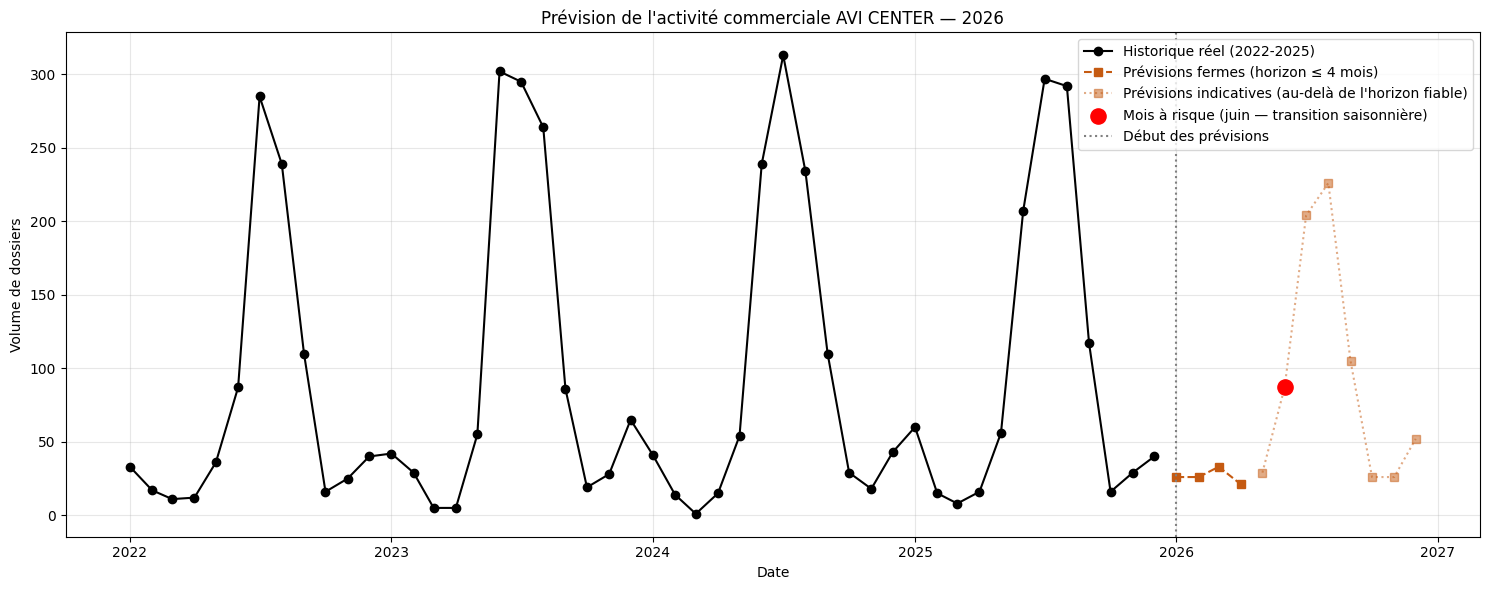

In [131]:
plt.figure(figsize=(15,6))

plt.plot(df['date'], df['volume'], label='Historique réel (2022-2025)', color='black', marker='o')

fermes = df_previsions_2026[df_previsions_2026['statut'] == 'Ferme']
indicatives = df_previsions_2026[df_previsions_2026['statut'] == 'Indicatif']

plt.plot(fermes['date'], fermes['volume_prevu'],
         label=f'Prévisions fermes (horizon ≤ {horizon_fiable} mois)',
         color='#C55A11', marker='s', linestyle='--')

plt.plot(indicatives['date'], indicatives['volume_prevu'],
         label='Prévisions indicatives (au-delà de l\'horizon fiable)',
         color='#C55A11', marker='s', linestyle=':', alpha=0.5)

# Mise en évidence visuelle du mois de juin, quel que soit son statut
juin_2026 = df_previsions_2026[df_previsions_2026['date'].dt.month == 6]
plt.scatter(juin_2026['date'], juin_2026['volume_prevu'], color='red', s=120,
            zorder=5, label='Mois à risque (juin — transition saisonnière)')

plt.axvline(x=pd.to_datetime('2026-01-01'), color='gray', linestyle=':', label='Début des prévisions')
plt.title("Prévision de l'activité commerciale AVI CENTER — 2026")
plt.xlabel("Date")
plt.ylabel("Volume de dossiers")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [132]:
#Détermination du niveau d'incertitude
df_previsions_2026['marge'] = df_previsions_2026['horizon'].map(erreur_par_horizon)
df_previsions_2026['marge'] = df_previsions_2026['marge'].fillna(erreur_par_horizon.max())

df_previsions_2026['volume_min'] = (df_previsions_2026['volume_prevu'] - df_previsions_2026['marge']).clip(lower=0).round()
df_previsions_2026['volume_max'] = (df_previsions_2026['volume_prevu'] + df_previsions_2026['marge']).round()

df_previsions_2026[['date','horizon','statut','volume_min','volume_prevu','volume_max']]

,date,horizon,statut,volume_min,volume_prevu,volume_max
0,2026-01-01,1,Ferme,16.0,26,36.0
1,2026-02-01,2,Ferme,20.0,26,32.0
2,2026-03-01,3,Ferme,17.0,33,49.0
3,2026-04-01,4,Ferme,17.0,21,25.0
4,2026-05-01,5,Indicatif,0.0,29,60.0
5,2026-06-01,6,Indicatif,0.0,87,227.0
6,2026-07-01,7,Indicatif,188.0,204,220.0
7,2026-08-01,8,Indicatif,197.0,226,255.0
8,2026-09-01,9,Indicatif,94.0,105,116.0
9,2026-10-01,10,Indicatif,17.0,26,35.0


### 7.5 Pics et creux 

In [133]:
previsions_fermes_seules = df_previsions_2026[df_previsions_2026['statut'] == 'Ferme']

top_pics = previsions_fermes_seules.nlargest(min(3, len(previsions_fermes_seules)), 'volume_prevu')[['date','volume_prevu']]
top_creux = previsions_fermes_seules.nsmallest(min(3, len(previsions_fermes_seules)), 'volume_prevu')[['date','volume_prevu']]

print(f"Mois à plus fort volume prévu (horizon ferme, {horizon_fiable} mois) :")
print(top_pics)
print(f"\nMois les plus creux prévus (horizon ferme, {horizon_fiable} mois) :")
print(top_creux)

Mois à plus fort volume prévu (horizon ferme, 4 mois) :
        date  volume_prevu
2 2026-03-01            33
0 2026-01-01            26
1 2026-02-01            26

Mois les plus creux prévus (horizon ferme, 4 mois) :
        date  volume_prevu
3 2026-04-01            21
0 2026-01-01            26
1 2026-02-01            26


### 7.6 Calendrier de recommendation

In [134]:
def recommandation(row):
    mois = row['mois_num']
    statut = row['statut']

    if mois == 6:
        return "⚠ Mois historiquement imprévisible (transition saisonnière) — quelle que soit la prévision affichée, prévoir une marge de manœuvre importante et ne pas s'engager sur un chiffre précis"
    elif statut == 'Indicatif':
        return "Prévision indicative — à confirmer plus près de l'échéance, ne pas engager de décision ferme"
    elif mois in [7,8]:
        return "Haute saison — renforcer les effectifs, anticiper le recrutement temporaire"
    elif mois in [3,10,11]:
        return "Basse saison — cibler la prospection, actions de fidélisation"
    else:
        return "Saison intermédiaire — maintenir l'activité standard"

df_previsions_2026['mois_num'] = df_previsions_2026['date'].dt.month
df_previsions_2026['recommandation'] = df_previsions_2026.apply(recommandation, axis=1)

calendrier_final = df_previsions_2026[['date','statut','volume_prevu','ca_prevu_millions','recommandation']]
calendrier_final.columns = ['Mois','Statut','Volume prévu','CA prévu (M FCFA)','Recommandation']
calendrier_final

,Mois,Statut,Volume prévu,CA prévu (M FCFA),Recommandation
0,2026-01-01,Ferme,26,8.06,Saison intermédiaire — maintenir l'activité st...
1,2026-02-01,Ferme,26,8.06,Saison intermédiaire — maintenir l'activité st...
2,2026-03-01,Ferme,33,10.23,"Basse saison — cibler la prospection, actions ..."
3,2026-04-01,Ferme,21,6.51,Saison intermédiaire — maintenir l'activité st...
4,2026-05-01,Indicatif,29,8.99,Prévision indicative — à confirmer plus près d...
5,2026-06-01,Indicatif,87,26.97,⚠ Mois historiquement imprévisible (transition...
6,2026-07-01,Indicatif,204,63.24,Prévision indicative — à confirmer plus près d...
7,2026-08-01,Indicatif,226,70.06,Prévision indicative — à confirmer plus près d...
8,2026-09-01,Indicatif,105,32.55,Prévision indicative — à confirmer plus près d...
9,2026-10-01,Indicatif,26,8.06,Prévision indicative — à confirmer plus près d...


### 7.7 Synthése chiffrée annuelle

In [140]:
volume_ferme = df_previsions_2026[df_previsions_2026['statut'] == 'Ferme']['volume_prevu'].sum()
volume_indicatif = df_previsions_2026[df_previsions_2026['statut'] == 'Indicatif']['volume_prevu'].sum()
volume_total_2026 = volume_ferme + volume_indicatif

ca_ferme = volume_ferme * TARIF_UNITAIRE
ca_total_2026 = volume_total_2026 * TARIF_UNITAIRE

print(f"Volume prévu sur l'horizon fiable ({horizon_fiable} mois, ferme) : {volume_ferme:.0f} dossiers")
print(f"Volume additionnel indicatif ({12-horizon_fiable} mois restants) : {volume_indicatif:.0f} dossiers")
print(f"Volume total estimé pour 2026 (ferme + indicatif) : {volume_total_2026:.0f} dossiers")
print(f"\nCA prévu sur l'horizon fiable : {ca_ferme/1_000_000:.1f} millions FCFA")
print(f"CA total estimé pour 2026 : {ca_total_2026/1_000_000:.1f} millions FCFA")

volume_moyen_historique = df.groupby('Années')['volume'].sum().mean()
croissance_prevue = ((volume_total_2026 - volume_moyen_historique) / volume_moyen_historique) * 100
print(f"\nVolume moyen annuel historique (2022-2025) : {volume_moyen_historique:.0f} dossiers")
print(f"Évolution prévue par rapport à la moyenne historique : {croissance_prevue:+.1f}%")

Volume prévu sur l'horizon fiable (4 mois, ferme) : 106 dossiers
Volume additionnel indicatif (8 mois restants) : 755 dossiers
Volume total estimé pour 2026 (ferme + indicatif) : 861 dossiers

CA prévu sur l'horizon fiable : 32.9 millions FCFA
CA total estimé pour 2026 : 266.9 millions FCFA

Volume moyen annuel historique (2022-2025) : 1092 dossiers
Évolution prévue par rapport à la moyenne historique : -21.2%


In [136]:
import os

os.makedirs('data_dashboard', exist_ok=True)

df.to_csv('data_dashboard/historique.csv', index=False)
df_scores.to_csv('data_dashboard/comparaison_modeles.csv', index=False)
df_previsions_2026.to_csv('data_dashboard/previsions_2026.csv', index=False)
calendrier_final.to_csv('data_dashboard/calendrier_recommandations.csv', index=False)
resultats.to_csv('data_dashboard/resultats_test_2025.csv', index=False)

print("Fichiers exportés dans le dossier data_dashboard/")

Fichiers exportés dans le dossier data_dashboard/
